# Analisis de Brauer sobre la Red de Citaciones de Canadas et al.

**Proyecto:** Brauer-(Author cite)-Data-Analysis — H index and probabilistic model

Este cuaderno muestra como construir una **configuracion de Brauer** $\Gamma = (\Gamma_0, \Gamma_1, \mu, \mathcal{O})$ a partir de la red de citaciones de Agustin Moreno Canadas, siguiendo:

- **Green & Schroll (2011):** Definicion de Brauer configuration algebras
- **Sierra (2018):** Formula para $\dim_k Z(\Lambda_\mathcal{M})$
- **Canadas, Rodriguez-Nieto, Salazar Diaz (2024):** BCA inducidas por particiones enteras (mathematics-12-03626-v2)
- **Instruccion de Agustin:** *"Ordenar por orden de publicacion en las secuencias de sucesores. Pword son los papers-multisets."*

### Interpretacion para citaciones

| Concepto Brauer | En la red de citaciones |
|---|---|
| $\Gamma_0$ (vertices) | Referencias (papers citados) |
| $\Gamma_1$ (poligonos) | Articulos de Canadas (multiconjuntos de sus refs) |
| $\mathcal{O}$ (orientacion) | Orden cronologico por ano de publicacion |
| $\operatorname{val}(y)$ | Numero de articulos de Canadas que citan a $y$ |
| $\mu(m)$ | Multiplicidad (garantiza $\operatorname{val}(m)\mu(m) > 1$) |
| $\delta_\mathcal{B}$ | Factor de impacto de la configuracion |
| $H(\mathcal{B})$ | Entropia (distribucion de influencia) |

## 1. Verificacion con el Ejemplo 2 del paper (particiones de 10)

Antes de aplicar a citaciones, verificamos que las formulas coinciden con el Example 5 del paper (mathematics-12-03626-v2, p.11):

$$L_1 = (4^{(2)} 2^{(1)}), \quad L_2 = (3^{(3)} 1^{(1)}), \quad L_3 = (2^{(5)})$$

Valores esperados: $\dim_k \Lambda_\mathcal{M} = 45$, $\#\text{Loops} = 10$, $\dim_k Z = 14$.

In [1]:
from aiq.brauer import BrauerConfiguration, example_partitions_of_10

bc_paper = example_partitions_of_10()

print("Ejemplo 2 del paper: particiones de 10 como branch data sobre S^2")
print(f"  L1 = (4^2, 2^1),  L2 = (3^3, 1^1),  L3 = (2^5)")
print(f"  M = {{1, 2, 3, 4}}\n")

for v in bc_paper.Gamma0:
    print(f"  val({v}) = {bc_paper.valency(v)},  mu({v}) = {bc_paper.mu(v)}")

print(f"\n  dim_k Lambda_M  = {bc_paper.dimension()}   (esperado: 45)")
print(f"  #Loops(Q_M)    = {bc_paper.n_loops()}   (esperado: 10)")
print(f"  dim_k Z(Lambda) = {bc_paper.center_dimension()}   (esperado: 14)")
print(f"  delta_B         = {bc_paper.impact_factor()}")
print(f"  H(B)            = {bc_paper.entropy():.4f}")

Ejemplo 2 del paper: particiones de 10 como branch data sobre S^2
  L1 = (4^2, 2^1),  L2 = (3^3, 1^1),  L3 = (2^5)
  M = {1, 2, 3, 4}

  val(1) = 1,  mu(1) = 2
  val(2) = 6,  mu(2) = 1
  val(3) = 3,  mu(3) = 1
  val(4) = 2,  mu(4) = 1

  dim_k Lambda_M  = 45   (esperado: 45)
  #Loops(Q_M)    = 10   (esperado: 10)
  dim_k Z(Lambda) = 14   (esperado: 14)
  delta_B         = 13
  H(B)            = 1.8339


## 2. Carga de la red de citaciones de Cañadas

Cargamos el JSON con los 17 articulos y sus 104 referencias. Cada articulo es un **poligono** $M_i \in \Gamma_1$ cuyo Pword (multiconjunto de referencias) esta ordenado por ano de publicacion.

In [3]:
from aiq.datasets import load_canadas_citation_network

bc, raw = load_canadas_citation_network()

print(f"Configuracion de Brauer de la red de citaciones")
print(f"  |Gamma_0| = {bc.n_vertices}  (referencias)")
print(f"  |Gamma_1| = {bc.n_polygons}  (articulos de Cañadas)")
print(f"\nPoligonos (articulos) ordenados por ano:")
for paper in raw["papers"]:
    pid = paper["id"]
    n_refs = len(paper.get("references", []))
    print(f"  {paper['year']}  {pid}  ({n_refs} refs)")

Configuracion de Brauer de la red de citaciones
  |Gamma_0| = 104  (referencias)
  |Gamma_1| = 17  (articulos de Cañadas)

Poligonos (articulos) ordenados por ano:
  2021  canadas2021mcnugget  (8 refs)
  2021  osorio2021emerging  (13 refs)
  2021  agudelo2021_01brauer  (12 refs)
  2022  canadas2022wargaming  (11 refs)
  2022  canadas2022categorification  (14 refs)
  2022  canadas2022dyck  (12 refs)
  2022  canadas2022snakegraphs  (15 refs)
  2022  osorio2022cayley  (13 refs)
  2023  canadas2023yangbaxter  (16 refs)
  2023  canadas2023kronecker  (9 refs)
  2023  canadas2023seaweeds  (17 refs)
  2023  canadas2023openshop  (8 refs)
  2023  canadas2023malware  (8 refs)
  2024  canadas2024cayley_nilpotent  (15 refs)
  2024  canadas2024partitions_coverings  (16 refs)
  2025  canadas2025tmto  (9 refs)
  2025  canadas2025rodriguez_thompson  (8 refs)


## 3. Analisis de Brauer completo

Calculamos todos los invariantes algebraicos de la configuracion:

- $\dim_k \Lambda_\mathcal{M} = 2|\mathcal{M}_1| + \sum_{m_i \in \mathcal{M}} \operatorname{val}(m_i)(\mu(m_i)\operatorname{val}(m_i) - 1)$ &emsp; (Formula 22)
- $\dim_k Z(\Lambda_\mathcal{M}) = 1 + \sum \mu(m) + |\mathcal{M}_1| - |M| + \#\text{Loops} - |\mathcal{C}_\mathcal{M}|$ &emsp; (Formula 23)
- $\delta_\mathcal{B} = \sum_{m \in M} \mu(m) \cdot \operatorname{val}(m)$ &emsp; (Factor de impacto)
- $H(\mathcal{B}) = -\sum_{m \in M} \frac{\mu(m)\operatorname{val}(m)}{\delta_\mathcal{B}} \log_2 \frac{\mu(m)\operatorname{val}(m)}{\delta_\mathcal{B}}$ &emsp; (Entropia)

In [4]:
analysis = bc.brauer_analysis()

print("=" * 60)
print("ANALISIS DE BRAUER — Red de Citaciones de Canadas et al.")
print("=" * 60)
print(f"  dim_k Lambda_M       = {analysis['dimension']}")
print(f"  dim_k Z(Lambda_M)    = {analysis['center_dimension']}")
print(f"  #Loops(Q_M)          = {analysis['n_loops']}")
print(f"  nu(D) (defecto)      = {analysis['defect']}")
print(f"  delta_B (impacto)    = {analysis['impact_factor_delta_B']}")
print(f"  H(B) (entropia)      = {analysis['entropy_H_B']:.6f}")
print(f"  Vertices truncados   = {len(analysis['truncated_vertices'])}")
print(f"  Vertices no-truncados = {len(analysis['nontruncated_vertices'])}")
print("=" * 60)

ANALISIS DE BRAUER — Red de Citaciones de Canadas et al.
  dim_k Lambda_M       = 1269
  dim_k Z(Lambda_M)    = 103
  #Loops(Q_M)          = 85
  nu(D) (defecto)      = 0
  delta_B (impacto)    = 289
  H(B) (entropia)      = 6.306225
  Vertices truncados   = 85
  Vertices no-truncados = 104


## 4. Valencias: las referencias mas influyentes

La valencia $\operatorname{val}(y)$ cuenta en cuantos articulos de Canadas aparece la referencia $y$. Las referencias con mayor valencia son los **pilares** de su produccion academica.

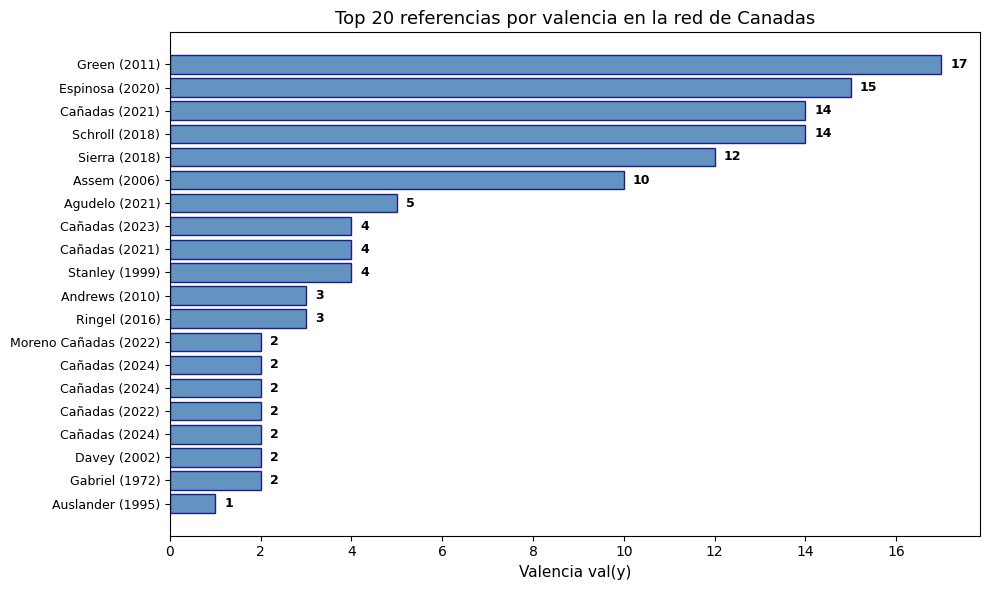

In [5]:
import matplotlib.pyplot as plt

# Obtener valencias y ordenar
vals = [(v, bc.valency(v)) for v in bc.Gamma0]
vals.sort(key=lambda x: -x[1])

# Resolver nombres completos
def ref_label(ref_id):
    rdata = raw["reference_pool"].get(ref_id, {})
    if not rdata:
        for p in raw["papers"]:
            if p["id"] == ref_id:
                rdata = p
                break
    authors = rdata.get("authors", ["?"])[0].split(",")[0]
    year = rdata.get("year", "?")
    return f"{authors} ({year})"

# Top 20
top = vals[:20]
labels = [ref_label(v) for v, _ in top]
values = [val for _, val in top]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top)), values, color="steelblue", edgecolor="navy", alpha=0.85)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Valencia val(y)", fontsize=11)
ax.set_title("Top 20 referencias por valencia en la red de Canadas", fontsize=13)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

## 5. Secuencias de sucesores (Pwords ordenados)

La secuencia de sucesores $S_y$ de un vertice $y$ lista los poligonos que contienen a $y$, ordenados por ano de publicacion (orientacion $\mathcal{O}$). Es la estructura ciclica que define el quiver de Brauer.

Mostramos la secuencia para **Green & Schroll (2011)**, la referencia mas citada (val = 17):

In [6]:
seqs = bc.successor_sequences()

# Secuencia de Green & Schroll 2011
ref_id = "green_schroll_2011"
seq = seqs[ref_id]
paper_years = {p["id"]: p["year"] for p in raw["papers"]}

print(f"Secuencia de sucesores de '{ref_id}' (val = {bc.valency(ref_id)}):")
print(f"  Orientacion O = orden por ano de publicacion\n")
for i, (pname, copy) in enumerate(seq):
    year = paper_years.get(pname, "?")
    arrow = " -->" if i < len(seq) - 1 else " --> (ciclico a 1)"
    print(f"  {i+1}. {pname} (ano {year}){arrow}")

# Tambien para una referencia con val bajo
ref2 = "sierra_2018"
seq2 = seqs[ref2]
print(f"\n\nSecuencia de sucesores de '{ref2}' (val = {bc.valency(ref2)}):")
for i, (pname, copy) in enumerate(seq2):
    year = paper_years.get(pname, "?")
    print(f"  {i+1}. {pname} (ano {year})")

Secuencia de sucesores de 'green_schroll_2011' (val = 17):
  Orientacion O = orden por ano de publicacion

  1. agudelo2021_01brauer (ano 2021) -->
  2. canadas2021mcnugget (ano 2021) -->
  3. osorio2021emerging (ano 2021) -->
  4. canadas2022categorification (ano 2022) -->
  5. canadas2022dyck (ano 2022) -->
  6. canadas2022snakegraphs (ano 2022) -->
  7. canadas2022wargaming (ano 2022) -->
  8. osorio2022cayley (ano 2022) -->
  9. canadas2023kronecker (ano 2023) -->
  10. canadas2023malware (ano 2023) -->
  11. canadas2023openshop (ano 2023) -->
  12. canadas2023seaweeds (ano 2023) -->
  13. canadas2023yangbaxter (ano 2023) -->
  14. canadas2024cayley_nilpotent (ano 2024) -->
  15. canadas2024partitions_coverings (ano 2024) -->
  16. canadas2025rodriguez_thompson (ano 2025) -->
  17. canadas2025tmto (ano 2025) --> (ciclico a 1)


Secuencia de sucesores de 'sierra_2018' (val = 12):
  1. agudelo2021_01brauer (ano 2021)
  2. canadas2021mcnugget (ano 2021)
  3. canadas2022categorificatio

## 6. Distribucion de valencias y entropia

La entropia $H(\mathcal{B})$ mide que tan uniforme es la distribucion de influencia. Si todas las referencias tuvieran la misma valencia, $H(\mathcal{B})$ seria maxima ($\log_2 |M|$). Un valor bajo indica concentracion en pocas referencias.

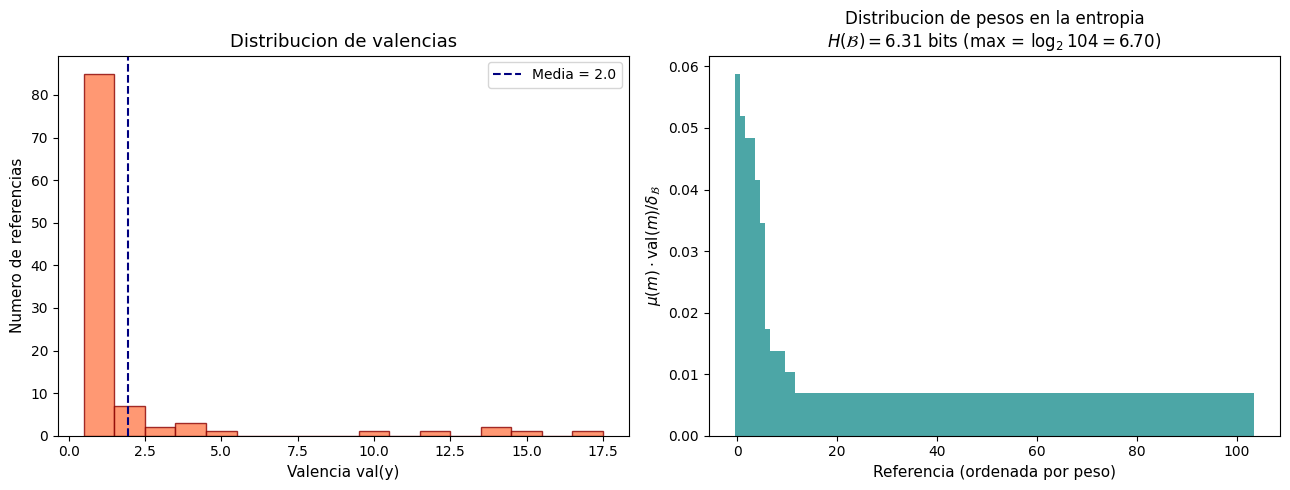

Entropia H(B)     = 6.3062 bits
Entropia maxima   = log2(104) = 6.7004 bits
Ratio H/H_max     = 0.9412  (1.0 = perfectamente uniforme)


In [7]:
import numpy as np

all_vals = sorted([bc.valency(v) for v in bc.Gamma0], reverse=True)
H_max = np.log2(bc.n_vertices)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma de valencias
ax1 = axes[0]
ax1.hist(all_vals, bins=range(1, max(all_vals) + 2), color="coral",
         edgecolor="darkred", alpha=0.8, align="left")
ax1.set_xlabel("Valencia val(y)", fontsize=11)
ax1.set_ylabel("Numero de referencias", fontsize=11)
ax1.set_title("Distribucion de valencias", fontsize=13)
ax1.axvline(np.mean(all_vals), color="navy", linestyle="--", linewidth=1.5,
            label=f"Media = {np.mean(all_vals):.1f}")
ax1.legend()

# Distribucion de pesos mu*val / delta_B (la que define H(B))
ax2 = axes[1]
delta_B = bc.impact_factor()
weights = sorted(
    [bc.mu(v) * bc.valency(v) / delta_B for v in bc.Gamma0],
    reverse=True
)
ax2.bar(range(len(weights)), weights, color="teal", alpha=0.7, width=1.0)
ax2.set_xlabel("Referencia (ordenada por peso)", fontsize=11)
ax2.set_ylabel(r"$\mu(m) \cdot \mathrm{val}(m) / \delta_\mathcal{B}$", fontsize=11)
ax2.set_title(
    f"Distribucion de pesos en la entropia\n"
    f"$H(\\mathcal{{B}}) = {bc.entropy():.2f}$ bits "
    f"(max = $\\log_2 {bc.n_vertices} = {H_max:.2f}$)",
    fontsize=12
)

plt.tight_layout()
plt.show()

print(f"Entropia H(B)     = {bc.entropy():.4f} bits")
print(f"Entropia maxima   = log2({bc.n_vertices}) = {H_max:.4f} bits")
print(f"Ratio H/H_max     = {bc.entropy() / H_max:.4f}  (1.0 = perfectamente uniforme)")

## 7. Quiver de Brauer $Q_\mathcal{M}$

El quiver de Brauer tiene como vertices los 17 articulos de Canadas y como flechas las relaciones de sucesion inducidas por las referencias compartidas. Lo visualizamos con NetworkX.

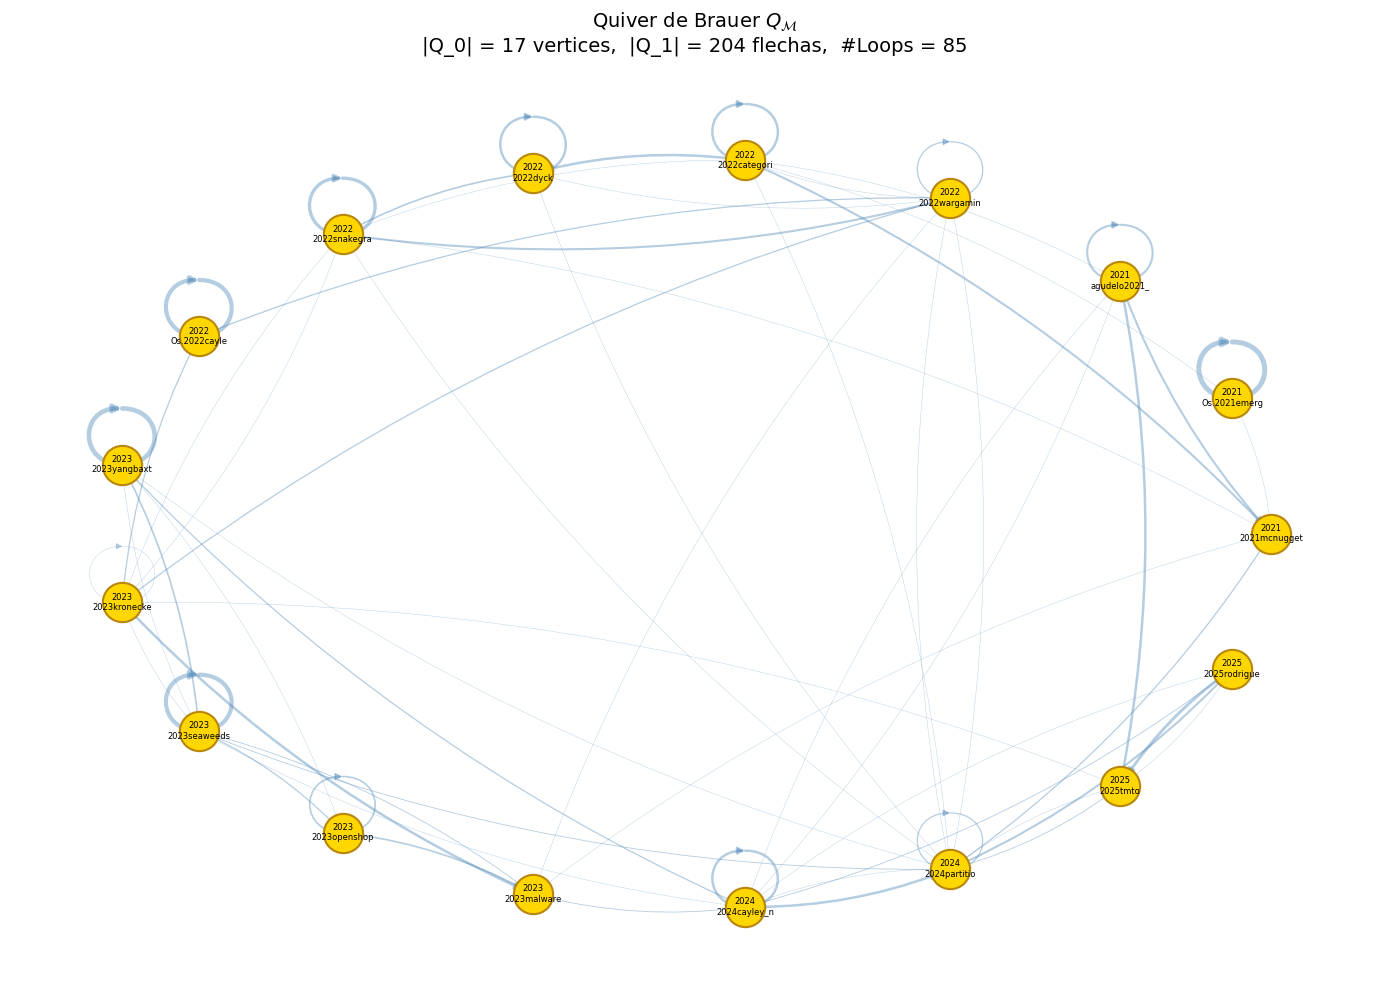

In [8]:
import networkx as nx

Q = bc.brauer_quiver()
G = Q.to_networkx()

# Etiquetas cortas
short_labels = {}
for node in G.nodes():
    year = paper_years.get(node, "")
    # Extraer sufijo descriptivo
    parts = str(node).replace("canadas", "").replace("osorio", "Os.")
    short_labels[node] = f"{year}\n{parts[:12]}"

fig, ax = plt.subplots(figsize=(14, 10))

# Layout circular (por la naturaleza ciclica de las secuencias de sucesores)
pos = nx.circular_layout(G)

# Contar flechas por par (para grosor)
edge_counts = {}
for u, v, _ in G.edges(keys=True):
    key = (u, v)
    edge_counts[key] = edge_counts.get(key, 0) + 1

# Dibujar
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=800, node_color="gold",
                       edgecolors="darkgoldenrod", linewidths=1.5)
nx.draw_networkx_labels(G, pos, labels=short_labels, ax=ax, font_size=6)

# Flechas con grosor proporcional a multiplicidad
for (u, v), count in edge_counts.items():
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)], ax=ax,
        width=min(count * 0.3, 4), alpha=0.4,
        edge_color="steelblue", arrows=True,
        arrowsize=10, connectionstyle="arc3,rad=0.1"
    )

ax.set_title(
    f"Quiver de Brauer $Q_\\mathcal{{M}}$\n"
    f"|Q_0| = {Q.n_vertices} vertices,  |Q_1| = {Q.n_arrows} flechas,  "
    f"#Loops = {bc.n_loops()}",
    fontsize=14
)
ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Conexion con el AIQ: efecto Mateo y trampas topologicas

La configuracion de Brauer y el AIQ se complementan:
- **Brauer** da invariantes **estaticos** ($\dim_k \Lambda$, $H(\mathcal{B})$, $\delta_\mathcal{B}$) que caracterizan la estructura algebraica de la red
- **AIQ** da la **dinamica** (como se propaga la influencia en el tiempo)

El **efecto Mateo** ($P(i) \propto k_i$, "los ricos se hacen mas ricos") se refleja en la distribucion de valencias: las referencias con alta valencia capturan mas peso en $\delta_\mathcal{B}$, concentrando la entropia.

In [9]:
# Efecto Mateo: las top 6 referencias (val >= 10) concentran que fraccion de delta_B?

delta_B = bc.impact_factor()
top_refs = [(v, bc.valency(v)) for v in bc.Gamma0 if bc.valency(v) >= 10]
top_refs.sort(key=lambda x: -x[1])
top_weight = sum(bc.mu(v) * bc.valency(v) for v, _ in top_refs)

print("Efecto Mateo en la red de Canadas:")
print(f"  {len(top_refs)} referencias con val >= 10 de un total de {bc.n_vertices}")
print(f"  Peso acumulado: {top_weight} / {delta_B} = {top_weight/delta_B:.1%} de delta_B\n")

for ref_id, val in top_refs:
    peso = bc.mu(ref_id) * val
    print(f"  {ref_label(ref_id):40s}  val={val:2d}  peso={peso:3d}  ({peso/delta_B:.1%})")

# Vertices truncados = trampas topologicas en terminologia AIQ
n_trunc = len(analysis["truncated_vertices"])
print(f"\nVertices truncados (val=1): {n_trunc} de {bc.n_vertices} ({n_trunc/bc.n_vertices:.0%})")
print("  Estas son referencias 'especializadas' que solo aparecen en un articulo.")
print("  En terminologia AIQ: son analogas a trampas topologicas (fuentes aisladas).")

Efecto Mateo en la red de Canadas:
  6 referencias con val >= 10 de un total de 104
  Peso acumulado: 82 / 289 = 28.4% de delta_B

  Green (2011)                              val=17  peso= 17  (5.9%)
  Espinosa (2020)                           val=15  peso= 15  (5.2%)
  Cañadas (2021)                            val=14  peso= 14  (4.8%)
  Schroll (2018)                            val=14  peso= 14  (4.8%)
  Sierra (2018)                             val=12  peso= 12  (4.2%)
  Assem (2006)                              val=10  peso= 10  (3.5%)

Vertices truncados (val=1): 85 de 104 (82%)
  Estas son referencias 'especializadas' que solo aparecen en un articulo.
  En terminologia AIQ: son analogas a trampas topologicas (fuentes aisladas).


## 9. Resumen

| Invariante | Valor | Interpretacion |
|---|---|---|
| $|\Gamma_0|$ | 104 | Total de referencias distintas |
| $|\Gamma_1|$ | 17 | Articulos de Canadas (2021-2025) |
| $\dim_k \Lambda_\mathcal{M}$ | 1269 | Dimension del algebra de configuracion de Brauer |
| $\dim_k Z(\Lambda_\mathcal{M})$ | 103 | Dimension del centro del algebra |
| $\delta_\mathcal{B}$ | 289 | Factor de impacto de Brauer |
| $H(\mathcal{B})$ | 6.31 bits | Entropia (de max 6.70) — concentracion moderada |
| #Loops | 85 | Ciclos especiales (refs que aparecen en un solo paper) |
| Ref. mas citada | Green & Schroll (2011) | Aparece en **todos** los 17 articulos (val=17) |